<a href="https://colab.research.google.com/github/EtzionR/LM4GeoAI/blob/main/SOL_1_Geo_Semantic_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solution for Ex 1: **Geo-Semantic Search**
### created by Etzion Harari | Geo-AI Course

[**https://github.com/EtzionR/LM4GeoAI**](https://github.com/EtzionR/LM4GeoAI)

## Prerequisites: pip install osmnx
[https://osmnx.readthedocs.io/en/stable/](https://osmnx.readthedocs.io/en/stable/)

In [40]:
!pip install osmnx

## Imports

In [41]:
from pandas.errors import SettingWithCopyWarning
from shapely import Point, Polygon
from time import time as get_time
from transformers import pipeline
from tqdm import tqdm

import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import osmnx as ox
import numpy as np
import warnings
import folium

## Ignore pandas Warning

In [42]:
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

## Global variables: EPSG codes (define the spatial reference systems)

In [43]:
WGS84_UTM_31N = "EPSG:32631"
WGS84_GEO_DD  = "EPSG:4326"


## Define Food type place_type in OSM data

In [44]:
FOOD = {'restaurant','fast_food','cafe'}
FOOD

{'cafe', 'fast_food', 'restaurant'}

### Eiffel Tower Location
WGS84 GEO DD X = 2.2944492, Y = 48.8583088

WGS84 GEO UTM 31N X = 448248, Y = 5411944

In [45]:
EIFFEL = Point(448248, 5411944)

## Display Eiffel Tower on the map

In [46]:

eiffecl_wgs84_dd = gpd.GeoSeries([EIFFEL], crs=WGS84_UTM_31N).to_crs(WGS84_GEO_DD).iloc[0]

eiffel_x, eiffel_y = eiffecl_wgs84_dd.x, eiffecl_wgs84_dd.y

fmap = folium.Map(location=[eiffel_y,eiffel_x], zoom_start=15, width=1500, height=500)
folium.Marker([eiffel_y,eiffel_x], popup="Tour Eiffel", tooltip="Tour Eiffel").add_to(fmap)
fmap

## OSM search parameters

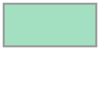

In [47]:
tags = {"amenity": True}

Paris = Polygon([(2.274507, 48.872479),
                 (2.351680, 48.872479),
                 (2.351680, 48.836947),
                 (2.274507, 48.836947),
                 (2.274507, 48.872479)])

Paris

## Load Data from OSM

In [48]:
START = get_time()

pois = ox.features_from_polygon(Paris, tags)

END = get_time()


print(f'Time to extarct data from OSM: {round(END-START,1)} seconds ({round((END-START)/60,1)} minutes)\n\n')

Time to extarct data from OSM: 15.0 seconds (0.3 minutes)




## Preprocess OSM data

In [49]:
pois = pois[['name', 'amenity', 'geometry']].dropna().rename(columns={'amenity':'place_type'}).to_crs(WGS84_UTM_31N)
pois['IsFood'] = pois.place_type.apply(lambda value: value in FOOD)

pois.head()

name      place_type  \
element id                                                  
node    21662099               Notre-Dame  ferry_terminal   
        29434739    Paris École Militaire     post_office   
        207782744           Paris Sentier     post_office   
        218117881  Parking Hôtel de Ville         parking   
        241110355  Bibliothèque Vaugirard         library   

                                         geometry  IsFood  
element id                                                 
node    21662099   POINT (452320.712 5411188.723)   False  
        29434739   POINT (449155.089 5411637.554)   False  
        207782744  POINT (452027.373 5412910.533)   False  
        218117881  POINT (452300.497 5411757.428)   False  
        241110355  POINT (448589.838 5410098.839)   False

# --------------------------------------------------------------------

## Q1

#### Display the ratio of food type POIs (using "IsFood" column)

In [50]:
is_food_rate = round(pois.IsFood.mean()*100,1)

print(f'{is_food_rate}% of POIs place_type are "Food related" (place_type = {FOOD})')


56.0% of POIs place_type are "Food related" (place_type = {'restaurant', 'fast_food', 'cafe'})


## Q2

#### Display the 10 most frequent **place_type**s

In [51]:
pois.place_type.value_counts().head(10)

,count
place_type,
restaurant,2958
cafe,817
fast_food,784
bar,556
bank,306
school,289
bicycle_rental,277
pharmacy,239
place_of_worship,116


## Q3

#### Calculate the distance (in meters) between each POI to Eiffel Tower

In [52]:
pois['distance_from_eiffel'] = pois.geometry.distance(EIFFEL).round(2)
pois.head()

name      place_type  \
element id                                                  
node    21662099               Notre-Dame  ferry_terminal   
        29434739    Paris École Militaire     post_office   
        207782744           Paris Sentier     post_office   
        218117881  Parking Hôtel de Ville         parking   
        241110355  Bibliothèque Vaugirard         library   

                                         geometry  IsFood  \
element id                                                  
node    21662099   POINT (452320.712 5411188.723)   False   
        29434739   POINT (449155.089 5411637.554)   False   
        207782744  POINT (452027.373 5412910.533)   False   
        218117881  POINT (452300.497 5411757.428)   False   
        241110355  POINT (448589.838 5410098.839)   False   

                   distance_from_eiffel  
element id                               
node    21662099                4142.15  
        29434739                 957.45  
        207782744               3901.01  
        218117881               4056.79  
        241110355               1876.56

## Q4

#### 1) Select the 100 POIs closest to the Eiffel Tower and construct a new DataFrame containing only these POIs.

#### 2) Calculate the maximum distance (in meters) from the Eiffel Tower among the POIs in the selected DataFrame

In [53]:
top_k = 100

eiffel_radius = pois.sort_values('distance_from_eiffel').iloc[:top_k]

max_distance = eiffel_radius.distance_from_eiffel.round(1).iloc[-1]

print(f'The farthest entity from Eiffel Tower is in a distance of {max_distance} meters\n')

eiffel_radius.shape



The farthest entity from Eiffel Tower is in a distance of 540.7 meters



(100, 5)

## Q5

#### Display the ratio of food type POIs, only for the 100 closest entities to Eiffel Tower (using "IsFood" column)

In [54]:
is_food_rate_eiffel = round(eiffel_radius.IsFood.mean()*100,1)

print(f'{is_food_rate_eiffel}% of POIs place_type are "Food related" (place_type = {FOOD})\n\n[Only for the closest {top_k} entities to Eiffel Tower]')


49.0% of POIs place_type are "Food related" (place_type = {'restaurant', 'fast_food', 'cafe'})

[Only for the closest 100 entities to Eiffel Tower]


## Q6

#### Display the 100 closest entities to Eiffel Tower, using folium

In [55]:
locations = eiffel_radius.geometry.to_crs(WGS84_GEO_DD).apply(lambda geometry: geometry if geometry.geom_type=='Point' else geometry.centroid)

fmap = folium.Map(location=[eiffel_y,eiffel_x], zoom_start=16, width=1500, height=500)

for location, name in zip(locations, eiffel_radius.name):
    folium.Marker([location.y ,location.x],
                  tooltip=name,
                  zIndexOffset=-1,
                  icon=folium.Icon(color='green', icon='flag')).add_to(fmap)

folium.Marker([eiffel_y,eiffel_x],
              tooltip="Tour Eiffel",
              icon=folium.Icon(color='blue',
                               icon='star-empty'),
              zIndexOffset=100).add_to(fmap)

fmap

## Q7

#### 1) Load the [multilingual-e5](https://huggingface.co/intfloat/multilingual-e5-large) language model using the **pipeline** interface for the **feature-extraction** task.

#### 2) Implement a function that takes a text string as input and returns a **single** embedding vector representing the text.

#### 3) Apply the function to a sample text and demonstrate the resulting embedding.



In [56]:
MODEL = "intfloat/multilingual-e5-large"

TEXT = "restaurant"

embedder = pipeline("feature-extraction", model=MODEL)

get_text_embedding = lambda text: np.array(embedder(text)[0]).max(0)

get_text_embedding(TEXT)

Device set to use cuda:0


array([ 1.23215389,  0.75919461, -0.2232188 , ..., -0.21436594,
       -0.850609  ,  1.06850421])

## Q8

#### Compute a text embedding for each place name (from the name column) corresponding to of the 100 closest entities to the Eiffel Tower (use the function from Q7.2).

In [57]:
eiffel_radius['repr'] = [get_text_embedding(text) for text in tqdm(eiffel_radius.name)]

eiffel_radius.head()

100%|██████████| 100/100 [00:03<00:00, 28.34it/s]


name       place_type  \
element id                                                 
way     308145239      Madame Brasserie       restaurant   
node    3135278479       Le Jules Verne       restaurant   
        3134285384    Paris Tour Eiffel      post_office   
        12801046288  Snacks Et Boissons        fast_food   
        3134287595     Caisse à billets  vending_machine   

                                                              geometry  \
element id                                                               
way     308145239    POLYGON ((448230.704 5411941.956, 448220.425 5...   
node    3135278479                       POINT (448251.491 5411925.21)   
        3134285384                      POINT (448251.664 5411906.687)   
        12801046288                     POINT (448281.755 5411971.577)   
        3134287595                       POINT (448196.353 5411939.74)   

                     IsFood  distance_from_eiffel  \
element id                                          
way     308145239      True                 10.87   
node    3135278479     True                 19.11   
        3134285384    False                 37.49   
        12801046288    True                 43.59   
        3134287595    False                 51.82   

                                                                  repr  
element id                                                              
way     308145239    [1.5537179708480835, 0.3098219931125641, 0.194...  
node    3135278479   [-0.6150420308113098, 0.5099128484725952, 0.22...  
        3134285384   [0.9651191830635071, 0.47746461629867554, 0.40...  
        12801046288  [1.0801331996917725, 0.6626086831092834, 0.310...  
        3134287595   [1.7954753637313843, 0.798403263092041, 0.2068...

## Q9

#### Using the function defined in Q7.2, compute the text embedding for the following free-text input:

``` sh
QUERY = "I want something to eat"

```

In [58]:
QUERY = "I want something to eat"

food_repr = get_text_embedding(QUERY)
food_repr

array([ 1.1345377 ,  0.15420584,  0.0966409 , ..., -0.47923836,
       -0.61367005,  0.19144896])

## Q10

#### 1) Compute the distance between the query embedding and each place-name embedding using the **L1 norm**.

#### 2) Compute the distance between the query embedding and each place-name embedding using the **L2 norm**.

#### 3) Compute the distance between the query embedding and each place-name embedding using **cosine similarity** based distance.

#### 4) As a baseline metric, generate a random value $r \sim U[0,1]$ for each place name.

# ------

## Additional details on the distance matrices are provided below:

$x$ - Embedding vector of given 100 POI place name

$q$ - Embedding vector of the input Query

$x,q \in \mathbb{R}^{n}$


distance functions:

 - L1 (Manhattan Distance): $L1(x, q) = \frac{1}{n}\sum_{i=1}^{n}|x_i-q_i|$
 - L2 (Euclidean Distance): $L2(x, q) = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-q_i)^{2}}$
 - CS (Cosine Similarity): $CS(x, q) = \frac{x^{t}q}{||x|| \cdot ||q||} = \frac{\sum_{i=1}^{n}(x_i \cdot q_i)}{\sqrt{\sum_{i=1}^{n}x_i^2} \cdot \sqrt{\sum_{i=1}^{n}q_i^2}} $


##

In [59]:
cosine_similarity = lambda vec1, vec2: np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

eiffel_radius['L1'] = eiffel_radius.repr.apply(lambda ary:  np.abs(food_repr - ary).mean())
eiffel_radius['L2'] = eiffel_radius.repr.apply(lambda ary: ((food_repr - ary)**2).mean()**.5)
eiffel_radius['CS'] = eiffel_radius.repr.apply(lambda ary:  1-cosine_similarity(food_repr, ary))
eiffel_radius['Random'] = np.random.rand(eiffel_radius.shape[0])

eiffel_radius.head()

name       place_type  \
element id                                                 
way     308145239      Madame Brasserie       restaurant   
node    3135278479       Le Jules Verne       restaurant   
        3134285384    Paris Tour Eiffel      post_office   
        12801046288  Snacks Et Boissons        fast_food   
        3134287595     Caisse à billets  vending_machine   

                                                              geometry  \
element id                                                               
way     308145239    POLYGON ((448230.704 5411941.956, 448220.425 5...   
node    3135278479                       POINT (448251.491 5411925.21)   
        3134285384                      POINT (448251.664 5411906.687)   
        12801046288                     POINT (448281.755 5411971.577)   
        3134287595                       POINT (448196.353 5411939.74)   

                     IsFood  distance_from_eiffel  \
element id                                          
way     308145239      True                 10.87   
node    3135278479     True                 19.11   
        3134285384    False                 37.49   
        12801046288    True                 43.59   
        3134287595    False                 51.82   

                                                                  repr  \
element id                                                               
way     308145239    [1.5537179708480835, 0.3098219931125641, 0.194...   
node    3135278479   [-0.6150420308113098, 0.5099128484725952, 0.22...   
        3134285384   [0.9651191830635071, 0.47746461629867554, 0.40...   
        12801046288  [1.0801331996917725, 0.6626086831092834, 0.310...   
        3134287595   [1.7954753637313843, 0.798403263092041, 0.2068...   

                           L1        L2        CS    Random  
element id                                                   
way     308145239    0.531372  0.655193  0.220901  0.967376  
node    3135278479   0.501194  0.631818  0.205022  0.303459  
        3134285384   0.545549  0.680671  0.239514  0.022904  
        12801046288  0.439309  0.551759  0.158156  0.373776  
        3134287595   0.527293  0.664171  0.228037  0.114164

## Q11

#### 1) For each $K \in \{ 5, 10, 25, 50, 100\}$, compute the **Precision@K** for the top-K closest places according to each distance metric (L1, L2, cosine similarity, random baseline, and the naive distance from the Eiffel Tower).

#### 2) Display the output results in as a pandas dataframe table




In [60]:

Ks = [5, 10, 25, 50, 100]

required_columns = [*eiffel_radius.columns[-4:]]+['distance_from_eiffel']

evaluation = {method:{k:0 for k in Ks} for method in required_columns}

for method in required_columns:
    for k in Ks:
      evaluation[method][k] = eiffel_radius.sort_values(method).IsFood[:k].mean()

evaluation = pd.DataFrame(evaluation)*100
evaluation.round(1)


,L1,L2,CS,Random,distance_from_eiffel
5,100.0,100.0,80.0,40.0,60.0
10,80.0,80.0,80.0,50.0,60.0
25,80.0,80.0,76.0,44.0,48.0
50,60.0,62.0,60.0,50.0,44.0
100,49.0,49.0,49.0,49.0,49.0


## Q12

#### 1) Compute **Precision@K** for each $K \in \{5,6,7, \cdot \cdot \cdot, 98, 99, 100 \}$ across all distance metrics (L1, L2, cosine similarity, random baseline, and the naive distance from the Eiffel Tower).

#### 2) Create a figure that visualizes **Precision@K** as a function of K for each distance metric.

#### 3) Add to the figure the proportion of food-related places among the 100 closest points of interest to the Eiffel Tower (as computed in Q5).

#### 4) Interpret and explain the results presented in the figure.


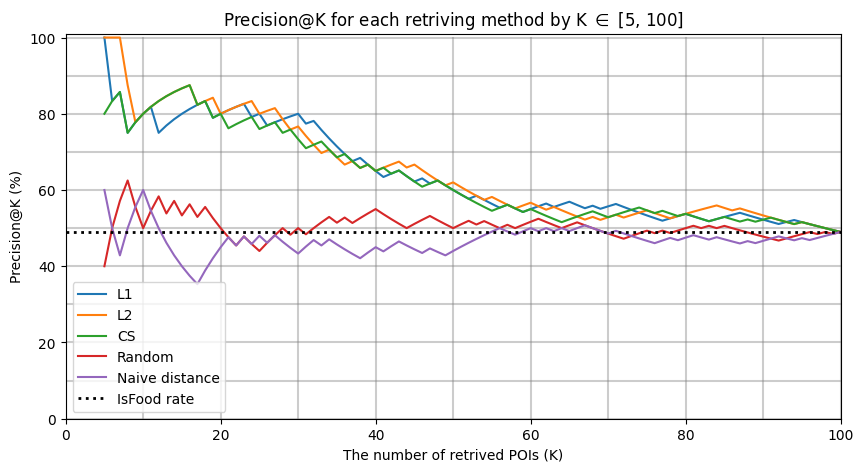

In [61]:
Ks = [k for k in range(5,101)]

required_columns = [*eiffel_radius.columns[-4:]]+['distance_from_eiffel']

evaluation = {method:{k:0 for k in Ks} for method in required_columns}

for method in required_columns:
    for k in Ks:
        eiffel_radius.sort_values(method).IsFood[:k].mean()
        evaluation[method][k] = eiffel_radius.sort_values(method).IsFood[:k].mean()

evaluation = pd.DataFrame(evaluation)*100

# ##############################################################################

plt.figure(figsize=(10,5))
plt.title(f'Precision@K for each retriving method by K $\\in$ [5, {top_k}]')
for col in evaluation.columns:
    plt.plot(evaluation.index, evaluation[col], label=col if col!='distance_from_eiffel' else 'Naive distance')

plt.plot([0, top_k], [is_food_rate_eiffel, is_food_rate_eiffel],
         color='k', lw=2, linestyle='dotted', label = 'IsFood rate')

for yi in np.linspace(0,100,11):
    plt.plot([0,top_k],[yi,yi], color='gray', alpha=.4, zorder=-1)

for xi in np.linspace(0,top_k,11):
    plt.plot([xi, xi],[0,100], color='gray', alpha=.4, zorder=-1)

plt.xlabel('The number of retrived POIs (K)')
plt.ylabel('Precision@K (%)')

plt.legend(loc='lower left')
plt.ylim(0,101)
plt.xlim(0,top_k)

plt.show()



## Q13

#### Identify the distance metric that achieves the highest **Precision@K** for $K<10$.

In [62]:
higher_score_column = evaluation[evaluation.index<10].idxmax(axis=1).value_counts().index[0]

print(f'The column with the higher score is {higher_score_column}')


The column with the higher score is L2


## Q14

#### Visualize the top 10 results according to the metric selected in Q13 on a Folium map, displayed alongside the Eiffel Tower.

In [63]:
N_best_locations = 10

best_locations = eiffel_radius.sort_values(higher_score_column).iloc[:N_best_locations]
best_locations_xy = best_locations.geometry.to_crs(WGS84_GEO_DD).apply(lambda geometry: geometry if geometry.geom_type=='Point' else geometry.centroid)

fmap = folium.Map(location=[eiffel_y,eiffel_x], zoom_start=15, width=1500, height=500)

for location, name in zip(best_locations_xy, best_locations.name):
    folium.Marker([location.y ,location.x],
                  tooltip=name,
                  zIndexOffset=100,
                  icon=folium.Icon(color='red', icon='cutlery')).add_to(fmap)

folium.Marker([eiffel_y,eiffel_x],
              tooltip="Tour Eiffel",
              icon=folium.Icon(color='blue',
                               icon='star-empty'),
              zIndexOffset=200).add_to(fmap)

fmap

## Q - Bonus

#### Compute **Precision@K** for $K=10$ among the 100 closest points of interest (POIs) to the Eiffel Tower using the L2 norm.

#### Perform this evaluation using text embeddings generated from the following language models:

- [google-bert/bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased)

- [almanach/camembert-large](https://huggingface.co/almanach/camembert-large)

- [intfloat/multilingual-e5-large](https://huggingface.co/intfloat/multilingual-e5-large)

#### Analyze and interpret the results, highlighting differences in performance across the models.

# Bon appétit!

Create by Etzion Harari | Geo-AI Course | [https://github.com/EtzionR/LM4GeoAI](https://github.com/EtzionR/LM4GeoAI)